In [1]:
from qiskit import qpy

In [88]:
from qiskit import QuantumCircuit
from qiskit import qpy
import numpy as np
from qiskit.quantum_info import Statevector, Operator, partial_trace

In [81]:
with open("C:/Users/szymon/QuditsOnQubits/QuditsOnQubits/basis_direct_encoding_benchmarks/quantum_circuits/two_qutrit/monomial_full__sup023_P102_ph000/graph_state_direct_basis.qpy", 'rb') as f:
      testqc = qpy.load(f)[0]

with open(r"C:\Users\szymon\QuditsOnQubits\QuditsOnQubits\basis_direct_encoding_benchmarks\quantum_circuits\two_qutrit\monomial_full__sup013_P102_ph000\graph_state_direct_basis_transpiled.qpy", 'rb') as f:
      qcsuptrans = qpy.load(f)[0]

with open(r"C:\Users\szymon\QuditsOnQubits\QuditsOnQubits\basis_direct_encoding_benchmarks\quantum_circuits\two_qutrit\monomial_full__sup013_P102_ph000\F3_W.qpy", 'rb') as f:
      F3sup = qpy.load(f)[0]
      
Esup = np.load(r"C:\Users\szymon\QuditsOnQubits\QuditsOnQubits\basis_direct_encoding_benchmarks\quantum_circuits\two_qutrit\monomial_full__sup013_P102_ph000\E.npy")

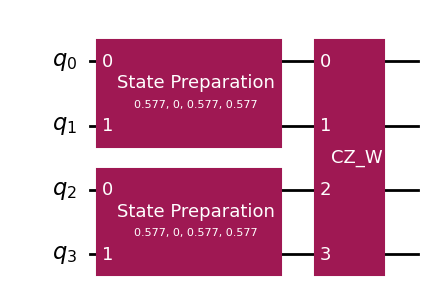

In [4]:
testqc.draw("mpl")

In [85]:
Statevector(testqc).draw('latex')

<IPython.core.display.Latex object>

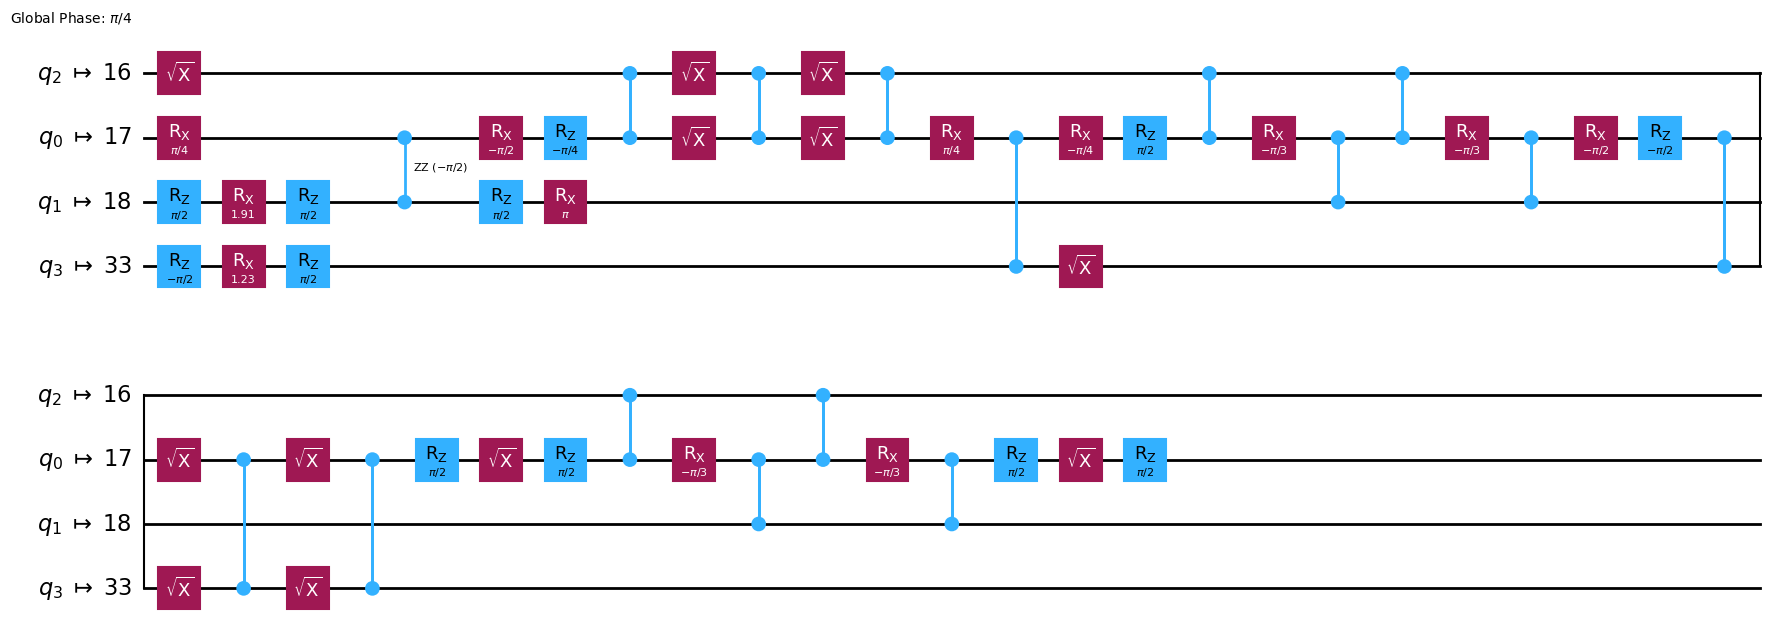

In [83]:
qcsuptrans.draw('mpl')

In [84]:
Esup

array([[0.+0.j, 1.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j]])

In [93]:
Operator(F3sup).draw('latex')

<IPython.core.display.Latex object>

In [92]:
Operator(Operator(F3sup).data.T.conjugate()).draw('latex')

<IPython.core.display.Latex object>

In [94]:
from qiskit.circuit.library import UnitaryGate

In [95]:
F3supdag = UnitaryGate(Operator(F3sup).data.T.conjugate())

In [98]:
from scipy.linalg import null_space

def complete_isometry_to_unitary(E, atol=1e-10):
    """
    E: 4x3 isometry, E.conj().T @ E = I_3.
    Returns U_E: 4x4 unitary with first three columns equal to E.
    """
    E = np.asarray(E, dtype=complex)

    if E.shape != (4, 3):
        raise ValueError(f"E must have shape (4,3), got {E.shape}")

    iso_err = np.linalg.norm(E.conj().T @ E - np.eye(3))
    if iso_err > atol:
        raise ValueError(f"E is not an isometry. Error = {iso_err}")

    # Vector orthogonal to all columns of E.
    complement = null_space(E.conj().T)

    if complement.shape != (4, 1):
        raise ValueError(f"Expected one-dimensional complement, got shape {complement.shape}")

    l = complement[:, 0]

    U_E = np.column_stack([E, l])

    unitary_err = np.linalg.norm(U_E.conj().T @ U_E - np.eye(4))
    if unitary_err > atol:
        raise ValueError(f"U_E is not unitary. Error = {unitary_err}")

    return U_E

In [103]:
Uesup = complete_isometry_to_unitary(Esup)

In [104]:
Uesupdag = Uesup.conjugate().T
Uedaggate = UnitaryGate(Uesupdag)

In [110]:
Ebase = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1], [0, 0, 0]])
Ebase

array([[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 0]])

In [112]:
Uesupdag @ Esup

array([[1.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j]])

In [108]:
basechangeqc = testqc.copy()

basechangeqc.append(F3supdag, [0, 1])

basechangeqc.append(Uedaggate, [0, 1])
basechangeqc.append(Uedaggate, [2, 3])

Statevector(basechangeqc).draw('latex')

<IPython.core.display.Latex object>

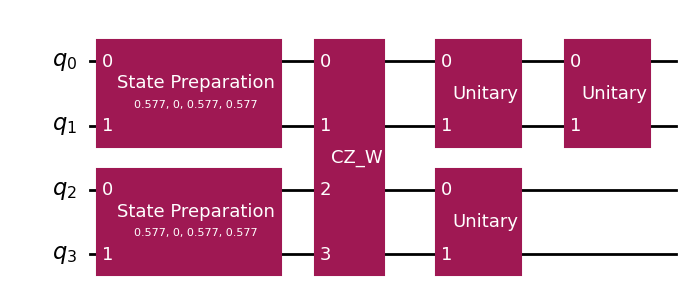

In [109]:
basechangeqc.draw('mpl')

In [6]:
Statevector(testqc).draw("latex")

<IPython.core.display.Latex object>

In [30]:
svqc = Statevector(testqc)

In [32]:
partial_trace(svqc, [0, 1]).draw('latex')

<IPython.core.display.Latex object>

In [43]:
def show_pt(path, dimred):
  with open(path, 'rb') as f:
    testqc = qpy.load(f)[0]

  return partial_trace(Statevector(testqc), [i for i in range(dimred + 1)])

In [9]:
with open("C:/Users/szymon/QuditsOnQubits/QuditsOnQubits/basis_direct_encoding_benchmarks/quantum_circuits/two_qutrit/baseline__E_old/graph_state_direct_basis.qpy", 'rb') as f:
      baseqc = qpy.load(f)[0]

In [44]:
show_pt("C:/Users/szymon/QuditsOnQubits/QuditsOnQubits/basis_direct_encoding_benchmarks/quantum_circuits/two_qutrit/baseline__E_old/graph_state_direct_basis.qpy", 1).draw('latex')

<IPython.core.display.Latex object>

In [51]:
show_pt(r"C:\Users\szymon\QuditsOnQubits\QuditsOnQubits\basis_direct_encoding_benchmarks\quantum_circuits\ghz3\monomial_full__sup023_P102_ph000\graph_state_direct_basis.qpy", 3).draw("latex")

<IPython.core.display.Latex object>

In [46]:
show_pt("C:/Users/szymon/QuditsOnQubits/QuditsOnQubits/basis_direct_encoding_benchmarks/quantum_circuits/two_qutrit/product__U_X__V_I/graph_state_direct_basis.qpy", 1).draw('latex')

<IPython.core.display.Latex object>

In [29]:
partial_trace(Statevector(baseqc), [0, 1]).draw('latex')

<IPython.core.display.Latex object>

In [11]:
import sys

sys.path.insert(0, r"C:\Users\szymon\QuditsOnQubits\QuditsOnQubits")

from QuditsOnQubits.create_ame_circuit import create_ame_circuit
from QuditsOnQubits.draw_graph import draw_graph


In [12]:
qc2, g2 = create_ame_circuit(2)

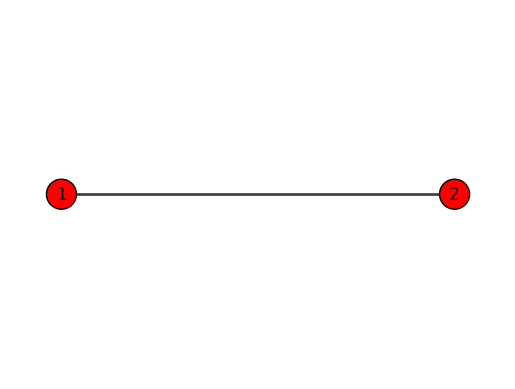

In [13]:
draw_graph(g2)

In [77]:
with open("C:/Users/szymon/QuditsOnQubits/QuditsOnQubits/quantum_circuits/FDAGgate3.qpy", 'rb') as f:
      F3dag = qpy.load(f)[0]

with open(r"C:\Users\szymon\QuditsOnQubits\QuditsOnQubits\quantum_circuits\CZgate3.qpy", 'rb') as f:
      CZ3 = qpy.load(f)[0]

with open(r"C:/Users/szymon/QuditsOnQubits/QuditsOnQubits/quantum_circuits/Fgate3.qpy", 'rb') as f:
      F3 = qpy.load(f)[0]

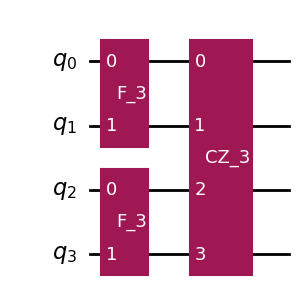

In [16]:
qc2.draw('mpl')

In [17]:
qc2.append(F3dag, [0, 1])

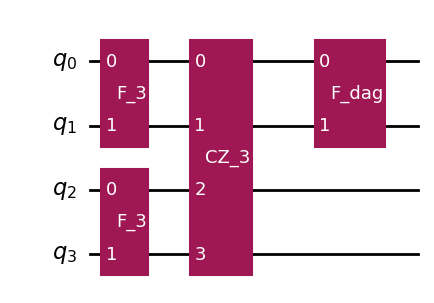

In [18]:
qc2.draw('mpl')

In [20]:
Statevector(qc2).draw('latex')

<IPython.core.display.Latex object>

In [27]:
partial_trace(Statevector(qc2), [0, 1]).draw('latex')

<IPython.core.display.Latex object>

In [71]:
qcghz, gghz = create_ame_circuit(n=3,graph_type='star')

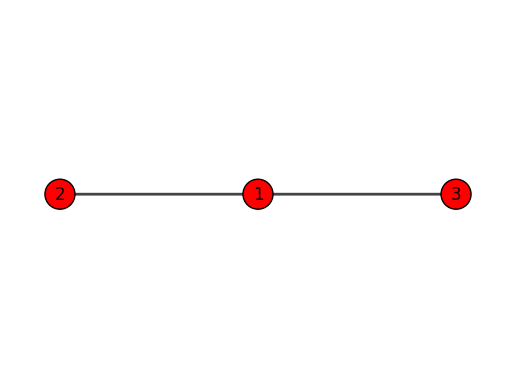

In [72]:
draw_graph(gghz)

In [73]:
qcghz.append(F3dag, [2, 3])
qcghz.append(F3dag, [4, 5])

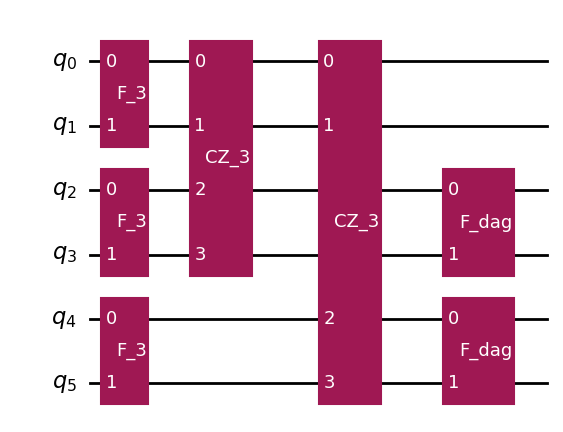

In [74]:
qcghz.draw('mpl')

In [75]:
Statevector(qcghz).draw('latex')

<IPython.core.display.Latex object>

In [60]:
import numpy as np

In [76]:
np.diag(partial_trace(Statevector(qcghz), [0, 1]).data).round(2)

array([0.33+0.j, 0.  +0.j, 0.  -0.j, 0.  -0.j, 0.  -0.j, 0.33-0.j,
       0.  -0.j, 0.  -0.j, 0.  +0.j, 0.  -0.j, 0.33+0.j, 0.  +0.j,
       0.  +0.j, 0.  +0.j, 0.  +0.j, 0.  +0.j])

In [78]:
ghztest = QuantumCircuit(6)
ghztest.append(F3, [0, 1])
ghztest.append(CZ3, [0, 1, 2, 3])
ghztest.append(CZ3, [2, 3, 4, 5])

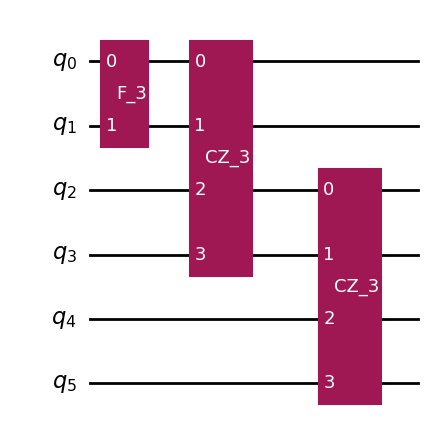

In [79]:
ghztest.draw('mpl')

In [80]:
Statevector(ghztest).draw('latex')

<IPython.core.display.Latex object>